# Filament Segmentation Pipeline

This notebook implements a data analysis pipeline for segmenting **brighter spots** (filaments) in microscopy images. We compare several classical image processing methods.

**Pipeline overview:**
1. Load raw multi-frame TIFF images from `workflow/data/`
2. Exploratory data analysis
3. Apply multiple segmentation methods
4. Visualise results

---
## 1. Setup and Configuration

We import the workflow classes from the `workflow` package and set the path to the raw image data. The dataset consists of multi-frame TIFF files (~900 frames per file) in the `workflow/data/` directory.

In [2]:
import sys
print("Python:", sys.executable)
print("CWD:", __import__("os").getcwd())

Python: /home/marmatt/miniforge3/envs/biohackathon/bin/python
CWD: /home/marmatt/Documents/BioHackathon2026


In [3]:
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

# Project root: directory containing workflow package (handles cwd = workspace root)
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "workflow" / "__init__.py").exists():
    PROJECT_ROOT = Path.cwd() / "BioHackathon2026"
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from workflow import (
    RawImageLoader,
    OtsuSegmenter,
    AdaptiveThresholdSegmenter,
    MorphologicalSegmenter,
    WatershedSegmenter,
    TopHatSegmenter,
    CLAHEThresholdSegmenter,
)
from workflow.experiments import (
    SampleCollector,
    SampleGridVisualizer,
    SegmentationVisualizer,
    AdaptiveParameterScan,
)

# Path to raw multi-frame TIFF files (~900 frames per file)
DATA_DIR = PROJECT_ROOT / "workflow" / "data"

print(f"Data directory: {DATA_DIR}")
print(f"Exists: {DATA_DIR.exists()}")

Data directory: /home/marmatt/Documents/BioHackathon2026/workflow/data
Exists: True


---
## 2. Load Dataset

We use `RawImageLoader` to load multi-frame TIFF files from the data directory. Each file contains ~900 frames; we can limit how many frames to load per file for faster iteration.

In [4]:
loader = RawImageLoader(str(DATA_DIR))

print(f"Number of TIFF files: {len(loader.files)}")
print(f"Total frames (all files): {len(loader)}")
if loader.files:
    n = loader.get_frame_count(loader.files[0])
    print(f"Frames in first file ({loader.files[0].name}): {n}")

Number of TIFF files: 9
Total frames (all files): 900
Frames in first file (ch20_URA7_URA8_001-crop1.tif): 100


---
## 3. Exploratory Data Analysis

We inspect intensity distributions, image statistics, and a few sample images. This helps us understand the data and choose appropriate segmentation strategies.

In [5]:
samples = SampleCollector(loader, max_total=20).run()

Intensity range: [0.0, 0.0]
Mean intensity: 0.00
Std intensity: 0.00


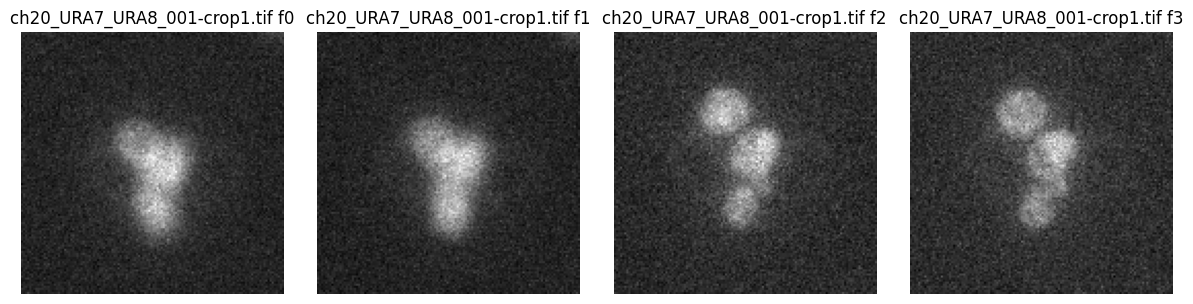

In [6]:
SampleGridVisualizer(samples, n_display=4).run()

---
## 4. Segmentation Methods

We apply several methods designed to detect **bright spots** (filaments) on darker backgrounds:

| Method | Description | Best for |
|--------|-------------|----------|
| **Otsu** | Global threshold minimising intra-class variance | Bimodal intensity |
| **Adaptive** | Local threshold per neighbourhood | Uneven illumination |
| **Morphological** | Percentile threshold + opening/closing | Noisy images |
| **Top-Hat** | Extracts small bright structures | Bright spots on dark bg |
| **Watershed** | Marker-based region separation | Overlapping structures |
| **CLAHE + Otsu** | Contrast enhancement then threshold | Low contrast |

In [7]:
# Instantiate all segmenters
segmenters = {
    "Otsu": OtsuSegmenter(),
    "Adaptive (15, gaussian)": AdaptiveThresholdSegmenter(block_size=15, method="gaussian"),
    "Morphological (p75)": MorphologicalSegmenter(threshold_percentile=75, open_radius=1, close_radius=2),
    "Top-Hat (r=3)": TopHatSegmenter(radius=3, threshold_percentile=50),
    "Watershed": WatershedSegmenter(min_distance=5, min_size=20, sigma=1.0),
    "CLAHE + Otsu": CLAHEThresholdSegmenter(clip_limit=0.03, tile_size=8),
}

### 4.1 Method 1: Otsu Thresholding

Otsu's method assumes a bimodal histogram and finds the threshold that best separates foreground (bright filaments) from background.

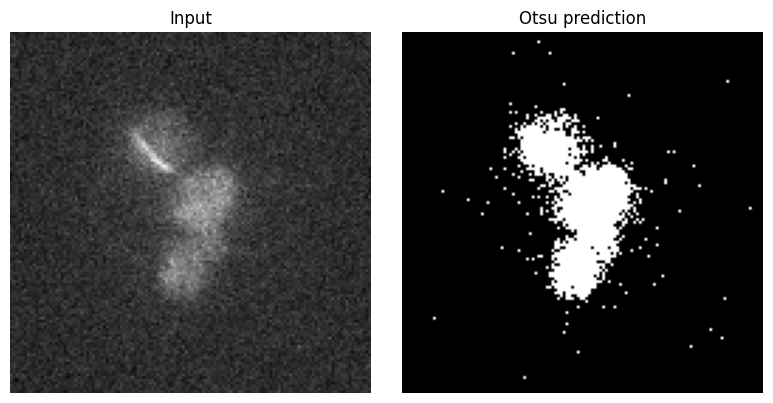

In [8]:
if samples:
    SegmentationVisualizer(segmenters["Otsu"], title="Otsu prediction").run(samples[10][1])

### 4.2 Method 2: Adaptive Thresholding

Adaptive thresholding computes a local threshold for each pixel based on its neighbourhood. Useful when illumination varies across the image.

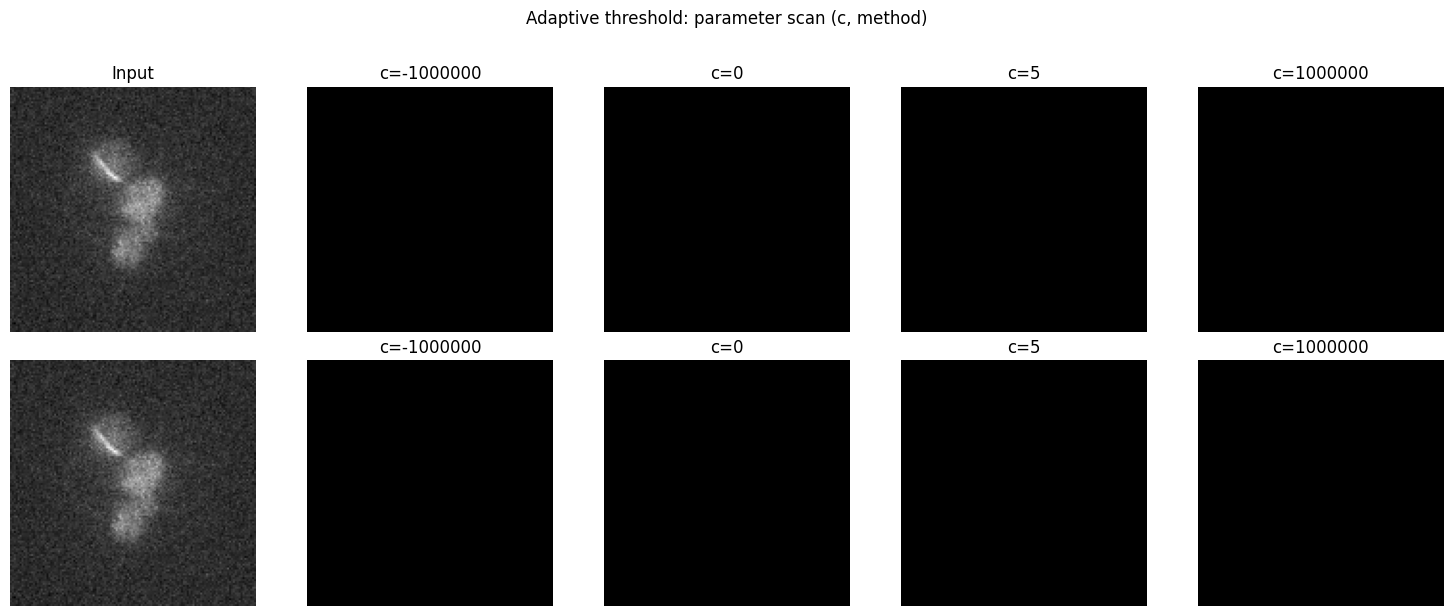

In [9]:
if samples:
    AdaptiveParameterScan(c_values=[-1000000, 0, 5, 1000000], methods=["gaussian", "mean"]).run(samples[10][1])

### 4.3 Method 3: Morphological (Percentile + Open/Close)

We threshold at a percentile (e.g. 75th) to capture bright pixels, then use morphological opening to remove small noise and closing to fill holes.

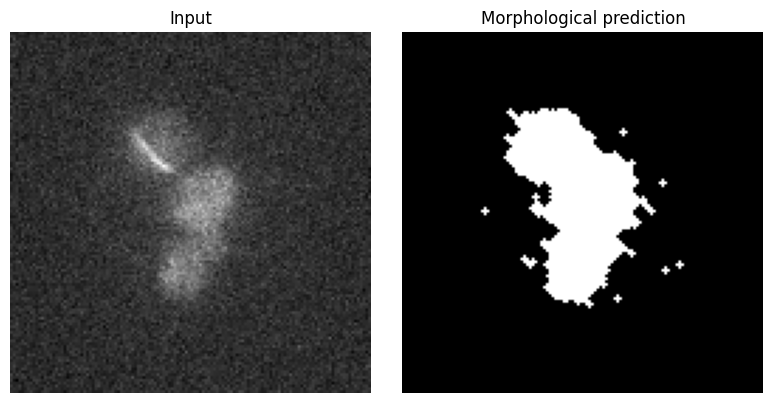

In [10]:
if samples:
    SegmentationVisualizer(segmenters["Morphological (p75)"], title="Morphological prediction").run(samples[10][1])

### 4.4 Method 4: Top-Hat (White Top-Hat)

White top-hat subtracts the morphological opening from the original image, isolating small bright structures. Ideal for bright spots on a dark background.

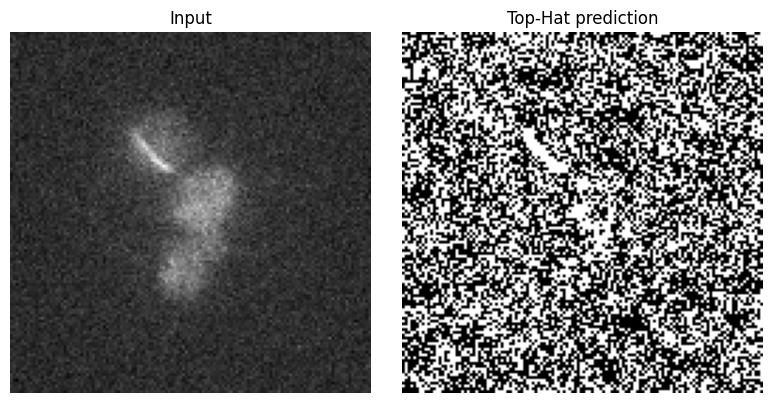

In [11]:
if samples:
    SegmentationVisualizer(segmenters["Top-Hat (r=3)"], title="Top-Hat prediction").run(samples[10][1])

### 4.5 Method 5: Watershed

Watershed segmentation uses local maxima as markers and floods from there. Good for separating overlapping bright regions.

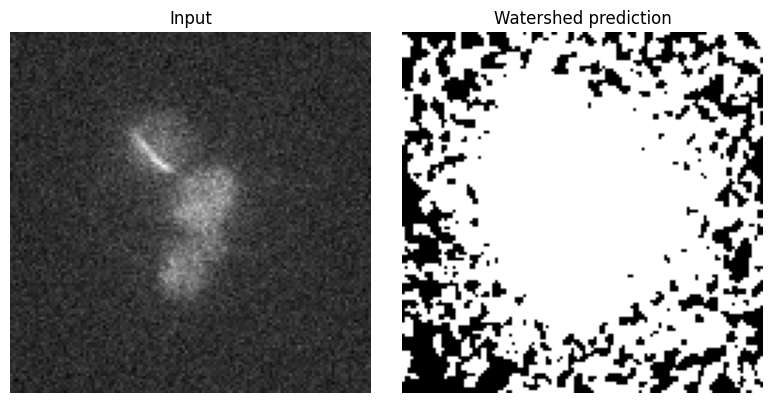

In [12]:
if samples:
    SegmentationVisualizer(segmenters["Watershed"], title="Watershed prediction").run(samples[10][1])

### 4.6 Method 6: CLAHE + Otsu

CLAHE (Contrast-Limited Adaptive Histogram Equalisation) enhances local contrast before applying Otsu. Useful for low-contrast images.

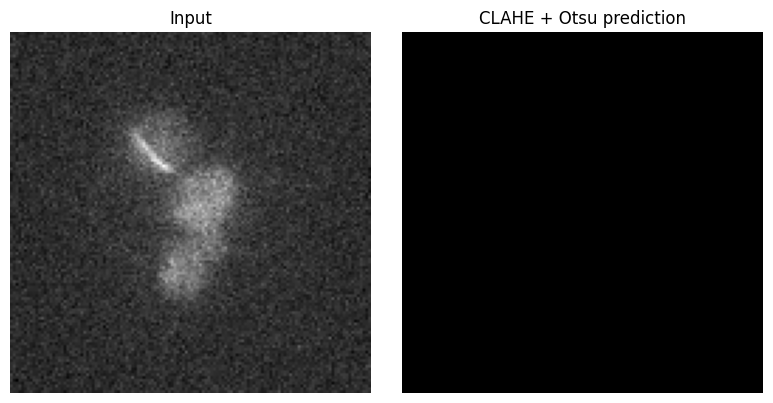

In [13]:
if samples:
    SegmentationVisualizer(segmenters["CLAHE + Otsu"], title="CLAHE + Otsu prediction").run(samples[10][1])

---
## 7. Segment Tracker Visualization

The **SegmentTracker** runs a chosen segmenter across the whole combined dataset and visualizes how segmentation evolves over time. All logic lives in `workflow/segment_tracker.py`.

**Filament vs. cell:** If the filament is only slightly brighter than the cell, use a **higher threshold** so only the brightest pixels (filament) are segmented. Tune the parameters in the cell below.

**Video view modes:** `overlay` (filled), `triple` (orig|mask|overlay), `contour` (outline), `skeleton` (centerline), `combined` (all overlaid: green fill + cyan contour + magenta skeleton). One video is saved per mode, plus a final combined video.

**Data outputs:** `get_results()` returns per-frame stats; `export_csv()` saves area, centroid, intensity to CSV.

**Options:**
- **Video**: Export an MP4 with chosen view mode
- **CSV**: Per-frame statistics for downstream analysis

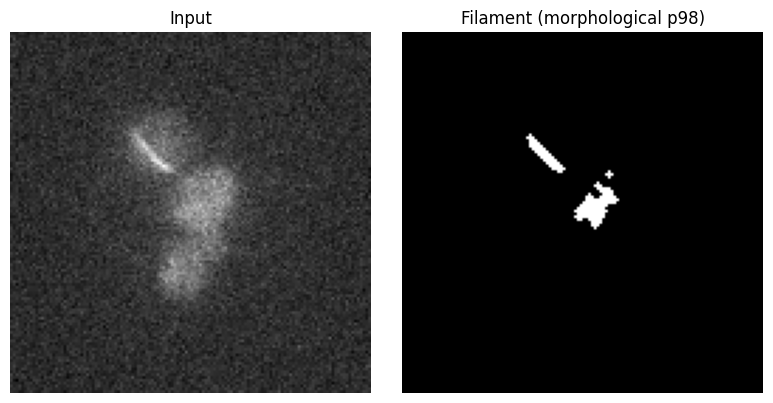

In [14]:
# Filament segmenter: tune these to isolate the filament (slightly brighter than cell)
# Higher threshold = only brightest pixels → use 90–98 for faint filaments
from workflow.segmentation import MorphologicalSegmenter, TopHatSegmenter

FILAMENT_THRESHOLD = 98   # Percentile: 90–98 faint filament, 75–85 bright
FILAMENT_METHOD = "morphological"  # "morphological" or "tophat"

if FILAMENT_METHOD == "morphological":
    filament_segmenter = MorphologicalSegmenter(
        threshold_percentile=FILAMENT_THRESHOLD,
        open_radius=1,
        close_radius=1,  # Smaller = less filling of cell interior
    )
else:
    filament_segmenter = TopHatSegmenter(
        radius=3,
        threshold_percentile=FILAMENT_THRESHOLD,  # Same param, applied to top-hat values
    )

# Quick preview on one frame
if samples:
    from workflow.experiments import SegmentationVisualizer
    SegmentationVisualizer(filament_segmenter, title=f"Filament ({FILAMENT_METHOD} p{FILAMENT_THRESHOLD})").run(samples[10][1])

In [15]:
import importlib
import workflow.segment_tracker
importlib.reload(workflow.segment_tracker)
from workflow.segment_tracker import SegmentTracker

# Use filament_segmenter from above (tune FILAMENT_THRESHOLD if needed)
tracker = SegmentTracker(
    segmenter=filament_segmenter,
    loader=loader,
    max_frames_per_file=50,   # Limit per TIFF for faster demo
    max_total=200,            # Cap total frames (set None for full dataset)
)

# Consistent colors across all videos: green, cyan, magenta
VIDEO_CONFIGS = [
    ("overlay", "green"),
    ("triple", "green"),
    ("contour", "cyan"),
    ("skeleton", "magenta"),
]

# Export one video per view mode
for view_mode, color in VIDEO_CONFIGS:
    out_path = tracker.run_video(
        output_path=PROJECT_ROOT / f"segment_tracker_{view_mode}.mp4",
        fps=10,
        overlay_alpha=0.4,
        show_side_by_side=True,
        view_mode=view_mode,
        overlay_color=color,
    )
    if out_path:
        print(f"Saved: {out_path.name}")

# Final video: all representations overlaid (green fill + cyan contour + magenta skeleton)
out_combined = tracker.run_video(
    output_path=PROJECT_ROOT / "segment_tracker_combined.mp4",
    fps=10,
    overlay_alpha=0.4,
    show_side_by_side=True,
    view_mode="combined",
)
if out_combined:
    print(f"Saved: {out_combined.name}")

Rendering 200 frames (overlay) to /home/marmatt/Documents/BioHackathon2026/segment_tracker_overlay.mp4...
Video saved to /home/marmatt/Documents/BioHackathon2026/segment_tracker_overlay.mp4
Saved: segment_tracker_overlay.mp4
Rendering 200 frames (triple) to /home/marmatt/Documents/BioHackathon2026/segment_tracker_triple.mp4...
Video saved to /home/marmatt/Documents/BioHackathon2026/segment_tracker_triple.mp4
Saved: segment_tracker_triple.mp4
Rendering 200 frames (contour) to /home/marmatt/Documents/BioHackathon2026/segment_tracker_contour.mp4...
Video saved to /home/marmatt/Documents/BioHackathon2026/segment_tracker_contour.mp4
Saved: segment_tracker_contour.mp4
Rendering 200 frames (skeleton) to /home/marmatt/Documents/BioHackathon2026/segment_tracker_skeleton.mp4...
Video saved to /home/marmatt/Documents/BioHackathon2026/segment_tracker_skeleton.mp4
Saved: segment_tracker_skeleton.mp4
Rendering 200 frames (combined) to /home/marmatt/Documents/BioHackathon2026/segment_tracker_combined

---
## 8. Hessian-Based Tubeness Filters

Classical threshold methods (Otsu, Morphological, Top-Hat) operate on **intensity alone** and cannot distinguish filaments from cells when both have similar brightness. **Hessian-based tubeness filters** analyse the eigenvalues of the Hessian matrix at each pixel to detect **elongated/ridge-like structures** (filaments) while suppressing **round/blob-like** structures (cells).

Three filters from `skimage.filters`:

| Filter | Designed for | Reference |
|--------|-------------|-----------|
| **Frangi** | Vessel-like tubular structures | Frangi et al. (1998) |
| **Meijering** | Neurites and thin filaments | Meijering et al. (2004) |
| **Sato** | Tubular structures (alt. response) | Sato et al. (1998) |

All three take `sigmas` (scale range matching filament width in pixels) and `threshold_percentile` (how strict the binarisation is).

### 8.1 Side-by-Side Comparison: Frangi vs Meijering vs Sato

We show the raw filter response (heatmap) and the binarised mask for each filter on the same sample frame.

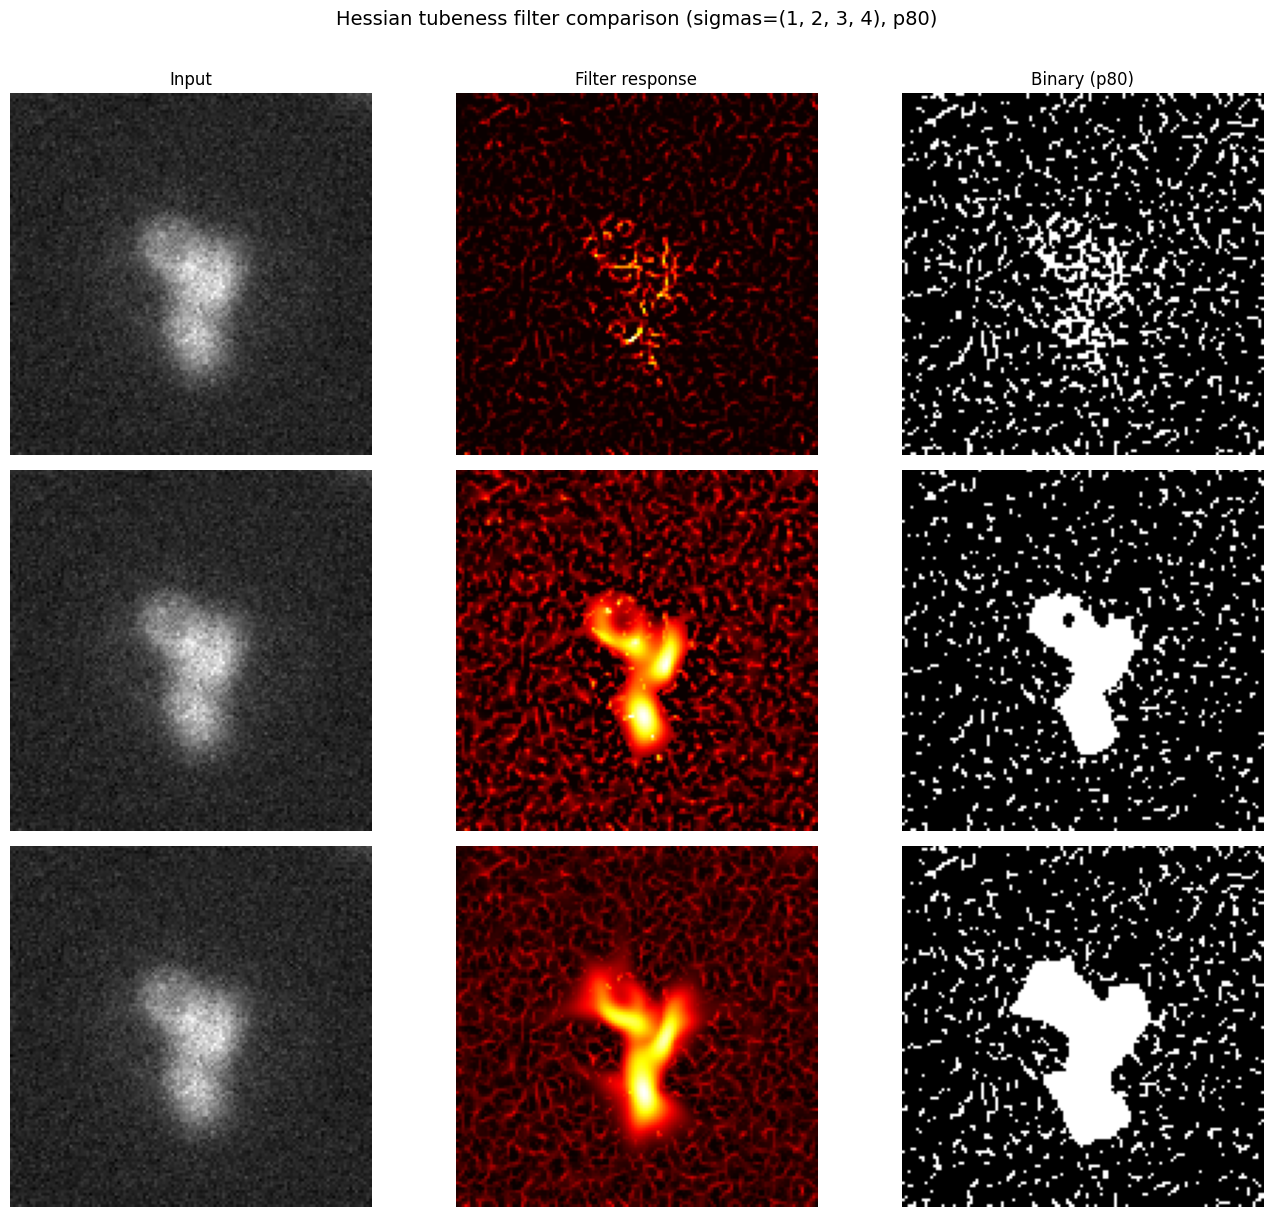

In [ ]:
import importlib, workflow.segmentation, workflow.experiments
importlib.reload(workflow.segmentation)
importlib.reload(workflow.experiments)
from workflow.experiments import TubenessComparisonExperiment

if samples:
    TubenessComparisonExperiment(
        sigmas=(1, 2, 3, 4),
        threshold_percentile=80,
        black_ridges=False,
    ).run(samples[10][1])

### 8.2 Individual Visualisation of Each Tubeness Filter

Quick preview of each filter's binary output.

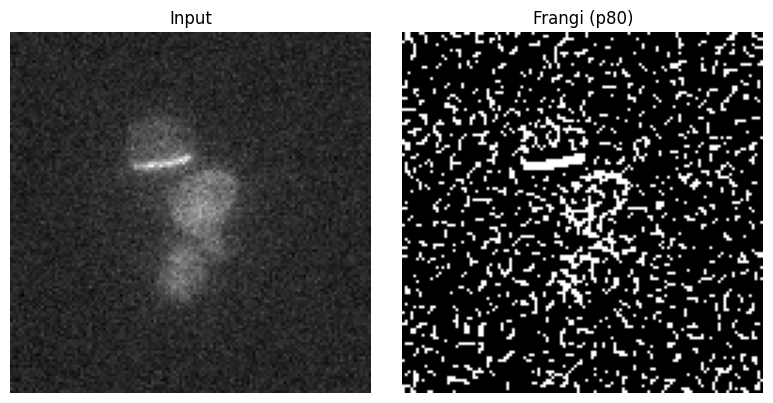

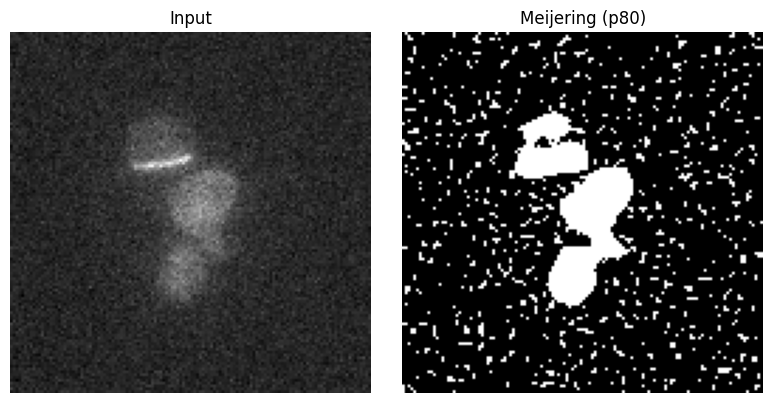

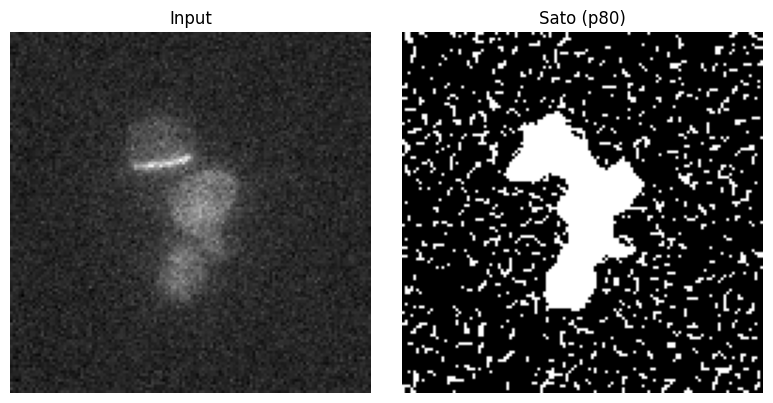

In [17]:
import importlib, workflow.segmentation
importlib.reload(workflow.segmentation)
from workflow.segmentation import FrangiSegmenter, MeijeringSegmenter, SatoSegmenter
from workflow.experiments import SegmentationVisualizer

TUBENESS_SIGMAS = (1, 2, 3, 4)
TUBENESS_THRESHOLD = 80

tubeness_segmenters = {
    "Frangi": FrangiSegmenter(sigmas=TUBENESS_SIGMAS, threshold_percentile=TUBENESS_THRESHOLD),
    "Meijering": MeijeringSegmenter(sigmas=TUBENESS_SIGMAS, threshold_percentile=TUBENESS_THRESHOLD),
    "Sato": SatoSegmenter(sigmas=TUBENESS_SIGMAS, threshold_percentile=TUBENESS_THRESHOLD),
}

if samples:
    for name, seg in tubeness_segmenters.items():
        SegmentationVisualizer(seg, title=f"{name} (p{TUBENESS_THRESHOLD})").run(samples[8][1])

### 8.3 Skeleton and Contour Videos for Each Tubeness Filter

We run each of the three Hessian-based segmenters through the SegmentTracker, saving **skeleton** (magenta) and **contour** (cyan) videos for comparison.

In [18]:
import importlib, workflow.segment_tracker
importlib.reload(workflow.segment_tracker)
from workflow.segment_tracker import SegmentTracker

for name, seg in tubeness_segmenters.items():
    tracker_tb = SegmentTracker(
        segmenter=seg,
        loader=loader,
        max_frames_per_file=50,
        max_total=200,
    )
    tag = name.lower()
    for view_mode, color in [("contour", "cyan"), ("skeleton", "magenta")]:
        out = tracker_tb.run_video(
            output_path=PROJECT_ROOT / f"tubeness_{tag}_{view_mode}.mp4",
            fps=10,
            overlay_alpha=0.4,
            show_side_by_side=True,
            view_mode=view_mode,
            overlay_color=color,
        )
        if out:
            print(f"  {out.name}")

Rendering 200 frames (contour) to /home/marmatt/Documents/BioHackathon2026/tubeness_frangi_contour.mp4...
Video saved to /home/marmatt/Documents/BioHackathon2026/tubeness_frangi_contour.mp4
  tubeness_frangi_contour.mp4
Rendering 200 frames (skeleton) to /home/marmatt/Documents/BioHackathon2026/tubeness_frangi_skeleton.mp4...
Video saved to /home/marmatt/Documents/BioHackathon2026/tubeness_frangi_skeleton.mp4
  tubeness_frangi_skeleton.mp4
Rendering 200 frames (contour) to /home/marmatt/Documents/BioHackathon2026/tubeness_meijering_contour.mp4...
Video saved to /home/marmatt/Documents/BioHackathon2026/tubeness_meijering_contour.mp4
  tubeness_meijering_contour.mp4
Rendering 200 frames (skeleton) to /home/marmatt/Documents/BioHackathon2026/tubeness_meijering_skeleton.mp4...
Video saved to /home/marmatt/Documents/BioHackathon2026/tubeness_meijering_skeleton.mp4
  tubeness_meijering_skeleton.mp4
Rendering 200 frames (contour) to /home/marmatt/Documents/BioHackathon2026/tubeness_sato_conto

In [19]:
# Export per-frame stats to CSV (area, centroid, intensity)
tracker.export_csv(PROJECT_ROOT / "segment_tracker_results.csv")

# Or get results as list of dicts for custom analysis
results = tracker.get_results()
import pandas as pd
df = pd.DataFrame(results)
display(df.head(10))

CSV saved to /home/marmatt/Documents/BioHackathon2026/segment_tracker_results.csv


,frame_idx,file_name,frame,area_px,centroid_y,centroid_x,mean_intensity,max_intensity
0,0,ch20_URA7_URA8_001-crop1.tif,0,222,67.725225,67.932432,0.003760,0.004288
1,1,ch20_URA7_URA8_001-crop1.tif,1,203,65.453202,67.965517,0.003738,0.004288
2,2,ch20_URA7_URA8_001-crop1.tif,2,192,51.015625,64.307292,0.003143,0.003586
3,3,ch20_URA7_URA8_001-crop1.tif,3,170,54.229412,67.782353,0.003038,0.003540
4,4,ch20_URA7_URA8_001-crop1.tif,4,182,51.637363,60.148352,0.003085,0.003922
5,5,ch20_URA7_URA8_001-crop1.tif,5,228,53.061404,65.434211,0.003059,0.003784
6,6,ch20_URA7_URA8_001-crop1.tif,6,203,54.822660,63.832512,0.003006,0.003571
7,7,ch20_URA7_URA8_001-crop1.tif,7,192,55.104167,62.093750,0.003013,0.003662
8,8,ch20_URA7_URA8_001-crop1.tif,8,214,56.233645,63.093458,0.002954,0.003967
9,9,ch20_URA7_URA8_001-crop1.tif,9,221,58.158371,60.778281,0.002998,0.005264


---
## 5. Next Steps

- **Hyperparameter tuning**: Adjust `block_size`, `threshold_percentile`, `radius`, etc. per method
- **Ensemble**: Combine predictions from top-performing methods
- **Deep learning**: Train a U-Net or similar model for improved segmentation